READ ME

Predicting Residentiall House Prices in Alabama Cities

Authors: Benson Zhang (bzz0033@auburn.edu), Nick Lagen (nwl0006@auburn.edu)

The dataset file is found on the Zillow research and uploaded to the notebook. This is the link https://www.zillow.com/research/data/ (Go to that link, and then use Data type ZHVI all homes and then geography city. For data types it was the first one with geography we used cities.

Our project uses machine learning regression to predict residentiall house values across Alabama cities using RMSE and R^2.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

Upload the Zillow Home Value Forecast for Birmingham AL

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving City_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv to City_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv


In [ ]:
df = pd.read_csv("City_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2000-01-31,2000-02-29,...,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,241379.142752,242663.718212,...,787759.105283,789717.516226,790640.585214,791461.883175,793508.724381,797069.260023,800930.010530,804071.070680,807526.733241,812534.060837
1,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,219879.639463,220212.561174,...,939219.114204,933655.414686,930555.357775,929724.364435,931860.325725,934790.567626,938290.634853,941935.364439,943140.514828,941985.227091
2,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,102873.725023,102847.587514,...,266750.428708,265583.284319,264649.841279,263822.373671,263140.339953,262570.192562,262293.039576,262341.494698,262281.884397,261975.575139
3,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,145345.781498,145384.613513,...,305218.233293,304958.127416,305196.821742,305554.020596,306554.024196,307725.085294,308984.170148,310111.723918,311072.088402,312456.527785
4,6915,4,San Antonio,city,TX,TX,"San Antonio-New Braunfels, TX",Bexar County,99081.995702,99173.981944,...,251023.711644,250004.622365,249335.650797,248973.791052,248708.039161,248319.381623,247945.314683,247659.767052,247366.111309,247131.767621


In [ ]:
cities = ["Birmingham", "Hoover", "Montgomery", "Huntsville", "Mobile", "Tuscaloosa"]

multi_df = df[(df["RegionName"].isin(cities)) & (df["State"] == "AL")].copy()

print(multi_df[["RegionName", "State"]].drop_duplicates())
print("Rows found:", len(multi_df))

     RegionName State
107      Mobile    AL
114  Birmingham    AL
140  Huntsville    AL
149  Montgomery    AL
332  Tuscaloosa    AL
654      Hoover    AL
Rows found: 6


In [ ]:
multi_df = multi_df.drop(columns=[
    "RegionID", "SizeRank", "RegionType",
    "StateName", "State", "Metro", "CountyName"
], errors="ignore")

multi_df.head()

,RegionName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,2000-06-30,2000-07-31,2000-08-31,2000-09-30,...,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28
107,Mobile,94940.680188,95134.302890,95373.903558,95808.918542,96397.706941,97021.687493,97719.470135,98290.502729,98707.840523,...,195535.128588,194858.572624,194244.928727,193676.049484,192994.661295,192434.702591,191894.039174,191640.383064,191471.154687,191839.544957
114,Birmingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,135534.023366,134924.817821,134734.156894,134965.289440,135288.680371,135519.832618,135487.476343,135241.827604,134919.987812,134654.902244
140,Huntsville,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68705.565360,68727.918168,...,282259.347643,282013.712840,281683.753923,281358.312588,281412.906347,281655.993053,281820.207948,281983.556071,282443.198277,283225.866768
149,Montgomery,90851.595908,90913.599962,90961.635016,91090.643641,91269.455467,91493.634535,91722.571897,91948.570266,92213.574500,...,145052.478537,144913.943315,145035.590725,145280.144023,145552.964348,146016.657965,146400.264277,146854.133346,147137.683563,147533.175007
332,Tuscaloosa,111003.282209,111384.385421,111782.640047,112362.410226,112824.627800,113189.624775,113731.365710,114337.670268,114876.269539,...,225807.571082,226267.212998,226728.877242,226789.268514,226913.734780,227044.587174,227136.584015,227376.136585,227359.607461,227725.772139


In [ ]:
multi_long = multi_df.melt(
    id_vars=["RegionName"],
    var_name="Date",
    value_name="Price"
)

multi_long["Date"] = pd.to_datetime(multi_long["Date"])
multi_long = multi_long.sort_values(["RegionName", "Date"]).reset_index(drop=True)
multi_long = multi_long.dropna()

multi_long.head()

,RegionName,Date,Price
20,Birmingham,2001-09-30,101451.761676
21,Birmingham,2001-10-31,101515.514820
22,Birmingham,2001-11-30,101616.109141
23,Birmingham,2001-12-31,101855.246503
24,Birmingham,2002-01-31,102194.793529


In [ ]:
multi_long["Year"] = multi_long["Date"].dt.year
multi_long["Month"] = multi_long["Date"].dt.month

In [ ]:
multi_long["Lag1"] = multi_long.groupby("RegionName")["Price"].shift(1)
multi_long["Lag2"] = multi_long.groupby("RegionName")["Price"].shift(2)
multi_long["Lag3"] = multi_long.groupby("RegionName")["Price"].shift(3)

multi_long = multi_long.dropna().reset_index(drop=True)

multi_long.head()

,RegionName,Date,Price,Year,Month,Lag1,Lag2,Lag3
0,Birmingham,2001-12-31,101855.246503,2001,12,101616.109141,101515.514820,101451.761676
1,Birmingham,2002-01-31,102194.793529,2002,1,101855.246503,101616.109141,101515.514820
2,Birmingham,2002-02-28,102610.639736,2002,2,102194.793529,101855.246503,101616.109141
3,Birmingham,2002-03-31,103036.251912,2002,3,102610.639736,102194.793529,101855.246503
4,Birmingham,2002-04-30,103393.969967,2002,4,103036.251912,102610.639736,102194.793529


In [ ]:
multi_long["CityLabel"] = multi_long["RegionName"]

multi_long = pd.get_dummies(multi_long, columns=["RegionName"], drop_first=True)

multi_long.head()

,Date,Price,Year,Month,Lag1,Lag2,Lag3,CityLabel,RegionName_Hoover,RegionName_Huntsville,RegionName_Mobile,RegionName_Montgomery,RegionName_Tuscaloosa
0,2001-12-31,101855.246503,2001,12,101616.109141,101515.514820,101451.761676,Birmingham,False,False,False,False,False
1,2002-01-31,102194.793529,2002,1,101855.246503,101616.109141,101515.514820,Birmingham,False,False,False,False,False
2,2002-02-28,102610.639736,2002,2,102194.793529,101855.246503,101616.109141,Birmingham,False,False,False,False,False
3,2002-03-31,103036.251912,2002,3,102610.639736,102194.793529,101855.246503,Birmingham,False,False,False,False,False
4,2002-04-30,103393.969967,2002,4,103036.251912,102610.639736,102194.793529,Birmingham,False,False,False,False,False


In [ ]:
multi_long["Year"] = multi_long["Date"].dt.year
multi_long["Month"] = multi_long["Date"].dt.month
feature_cols = ["Year", "Month", "Lag1", "Lag2", "Lag3"] + [
    col for col in multi_long.columns if col.startswith("RegionName_")
]

X = multi_long[feature_cols]
y = multi_long["Price"]

print("Features:")
print(feature_cols)
print()
print(X.head())

Features:
['Year', 'Month', 'Lag1', 'Lag2', 'Lag3', 'RegionName_Hoover', 'RegionName_Huntsville', 'RegionName_Mobile', 'RegionName_Montgomery', 'RegionName_Tuscaloosa']

   Year  Month           Lag1           Lag2           Lag3  \
0  2001     12  101616.109141  101515.514820  101451.761676   
1  2002      1  101855.246503  101616.109141  101515.514820   
2  2002      2  102194.793529  101855.246503  101616.109141   
3  2002      3  102610.639736  102194.793529  101855.246503   
4  2002      4  103036.251912  102610.639736  102194.793529   

   RegionName_Hoover  RegionName_Huntsville  RegionName_Mobile  \
0              False                  False              False   
1              False                  False              False   
2              False                  False              False   
3              False                  False              False   
4              False                  False              False   

   RegionName_Montgomery  RegionName_Tuscaloosa  
0   

In [ ]:
train_parts = []
test_parts = []

for city in multi_long["CityLabel"].unique():
    city_df = multi_long[multi_long["CityLabel"] == city].sort_values("Date").copy()
    split_idx = int(len(city_df) * 0.8)

    train_parts.append(city_df.iloc[:split_idx])
    test_parts.append(city_df.iloc[split_idx:])

train_df = pd.concat(train_parts).sort_values(["CityLabel", "Date"]).reset_index(drop=True)
test_df = pd.concat(test_parts).sort_values(["CityLabel", "Date"]).reset_index(drop=True)

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print(test_df["CityLabel"].value_counts())

X_train = train_df[feature_cols]
y_train = train_df["Price"]

X_test = test_df[feature_cols]
y_test = test_df["Price"]

Train rows: 1447
Test rows: 367
CityLabel
Montgomery    63
Mobile        63
Tuscaloosa    63
Huntsville    60
Hoover        59
Birmingham    59
Name: count, dtype: int64


# Training Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_preds = lin_model.predict(X_test)

lin_rmse = np.sqrt(mean_squared_error(y_test, lin_preds))
lin_r2 = r2_score(y_test, lin_preds)

print("Linear Regression RMSE:", lin_rmse)
print("Linear Regression R^2:", lin_r2)

Linear Regression RMSE: 572.2057695779869
Linear Regression R^2: 0.999961639954905


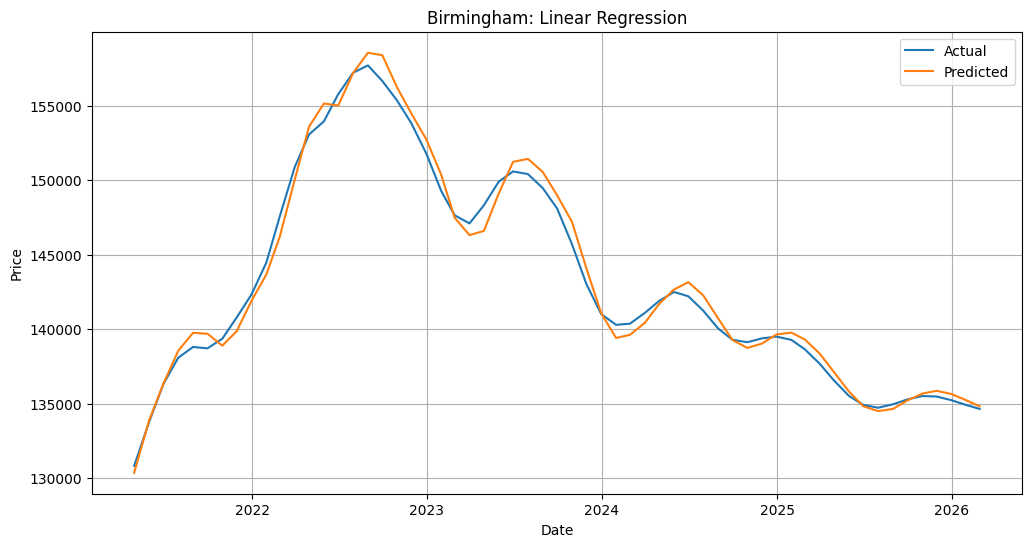

In [ ]:
bham_plot = test_df.copy()
bham_plot["Actual"] = y_test.values
bham_plot["Pred_LIN"] = lin_preds
bham_plot = bham_plot[bham_plot["CityLabel"] == "Birmingham"].copy()

plt.figure(figsize=(12,6))
plt.plot(bham_plot["Date"], bham_plot["Actual"], label="Actual")
plt.plot(bham_plot["Date"], bham_plot["Pred_LIN"], label="Predicted")
plt.title("Birmingham: Linear Regression")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# Train Random Forests

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R^2:", rf_r2)

Random Forest RMSE: 28586.793293378087
Random Forest R^2: 0.9042573317260886


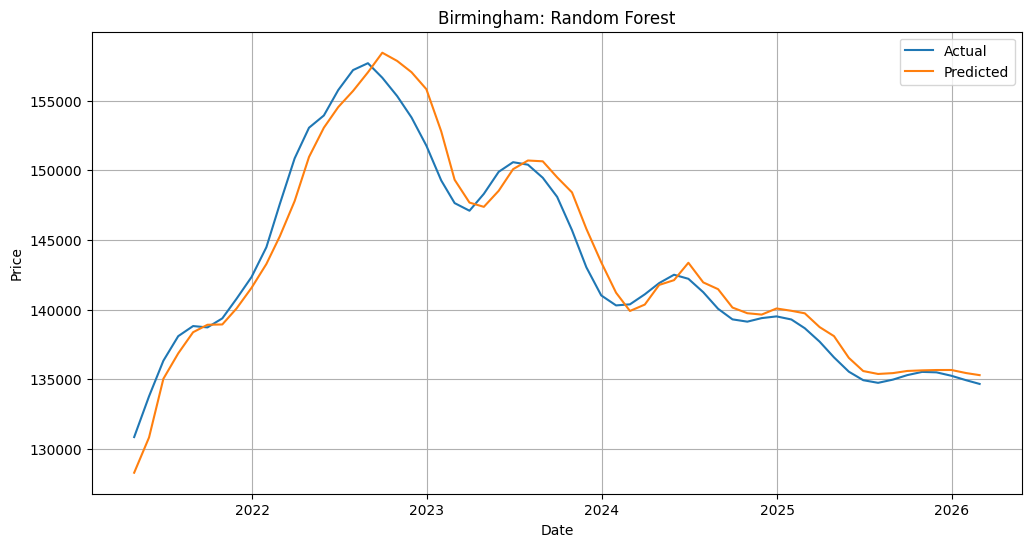

In [ ]:
bham_plot = test_df.copy()
bham_plot["Actual"] = y_test.values
bham_plot["Pred_RF"] = rf_preds
bham_plot = bham_plot[bham_plot["CityLabel"] == "Birmingham"].copy()

plt.figure(figsize=(12,6))
plt.plot(bham_plot["Date"], bham_plot["Actual"], label="Actual")
plt.plot(bham_plot["Date"], bham_plot["Pred_RF"], label="Predicted")
plt.title("Birmingham: Random Forest")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# Train Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train, y_train)

gbr_preds = gbr_model.predict(X_test)

gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_preds))
gbr_r2 = r2_score(y_test, gbr_preds)

print("Gradient Boosting RMSE:", gbr_rmse)
print("Gradient Boosting R^2:", gbr_r2)

Gradient Boosting RMSE: 27490.86333678216
Gradient Boosting R^2: 0.9114575771426106


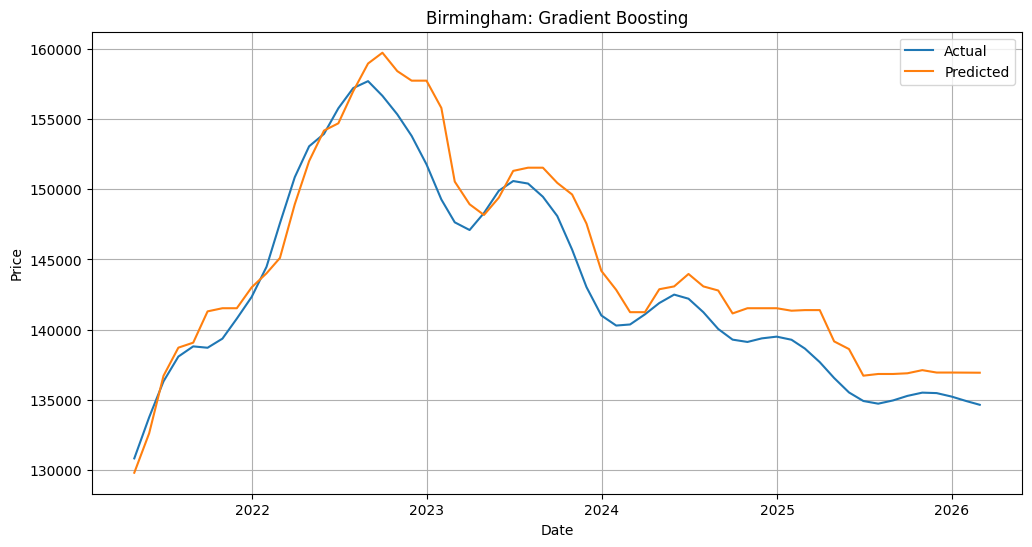

In [ ]:
bham_plot = test_df.copy()
bham_plot["Actual"] = y_test.values
bham_plot["Pred_GBR"] = gbr_preds
bham_plot = bham_plot[bham_plot["CityLabel"] == "Birmingham"].copy()

plt.figure(figsize=(12,6))
plt.plot(bham_plot["Date"], bham_plot["Actual"], label="Actual")
plt.plot(bham_plot["Date"], bham_plot["Pred_GBR"], label="Predicted")
plt.title("Birmingham: Gradient Boosting")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# Compare the Models

In [ ]:
print("Model Comparison")
print("----------------")
print("Linear Regression RMSE:", lin_rmse)
print("Linear Regression R^2:", lin_r2)
print()
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R^2:", rf_r2)
print()
print("Gradient Boosting RMSE:", gbr_rmse)
print("Gradient Boosting R^2:", gbr_r2)

Model Comparison
----------------
Linear Regression RMSE: 572.2057695779869
Linear Regression R^2: 0.999961639954905

Random Forest RMSE: 28586.793293378087
Random Forest R^2: 0.9042573317260886

Gradient Boosting RMSE: 27490.86333678216
Gradient Boosting R^2: 0.9114575771426106


Birmingham test rows: 59


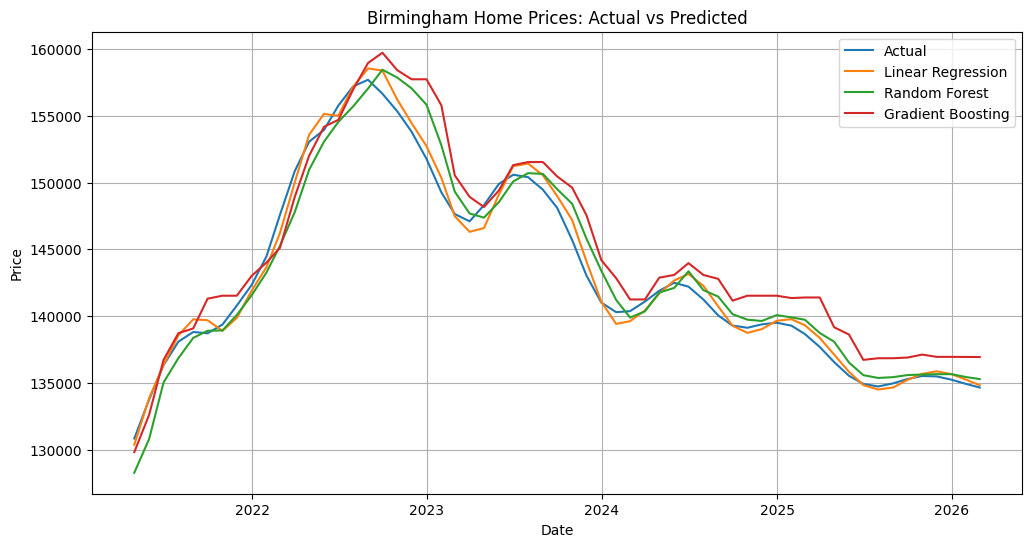

In [ ]:
plot_df = test_df.copy()

plot_df["Actual"] = y_test.values
plot_df["Pred_LIN"] = lin_preds
plot_df["Pred_RF"] = rf_preds
plot_df["Pred_GBR"] = gbr_preds

bham_plot = plot_df[plot_df["CityLabel"] == "Birmingham"].copy()

print("Birmingham test rows:", len(bham_plot))

plt.figure(figsize=(12,6))
plt.plot(bham_plot["Date"], bham_plot["Actual"], label="Actual")
plt.plot(bham_plot["Date"], bham_plot["Pred_LIN"], label="Linear Regression")
plt.plot(bham_plot["Date"], bham_plot["Pred_RF"], label="Random Forest")
plt.plot(bham_plot["Date"], bham_plot["Pred_GBR"], label="Gradient Boosting")
plt.title("Birmingham Home Prices: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()